In [11]:
import pandas as pd


In [12]:
df = pd.read_csv(r"C:\Users\LIGHTRQX\Downloads\Fraud.csv")
df.info()
df.describe()
df['isFraud'].value_counts(normalize=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64

In [13]:
df = df[~((df['amount'] > df['oldbalanceOrg']) & (df['newbalanceOrig'] > df['oldbalanceOrg']))]

In [14]:

df['errorBalanceOrig'] = df['oldbalanceOrg'] - df['amount'] - df['newbalanceOrig']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']


In [15]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,errorBalanceOrig,errorBalanceDest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,0.0,9839.64
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,0.0,1864.28
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,0.0,181.00
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,0.0,21363.00
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,0.0,11668.14


C:\Users\LIGHTRQX\AppData\Local\Temp\ipykernel_15376\3483216613.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['isFraud'] == 1]['errorBalanceDest'], label='Fraud', shade=True)
C:\Users\LIGHTRQX\AppData\Local\Temp\ipykernel_15376\3483216613.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['isFraud'] == 0]['errorBalanceDest'], label='Not Fraud', shade=True)


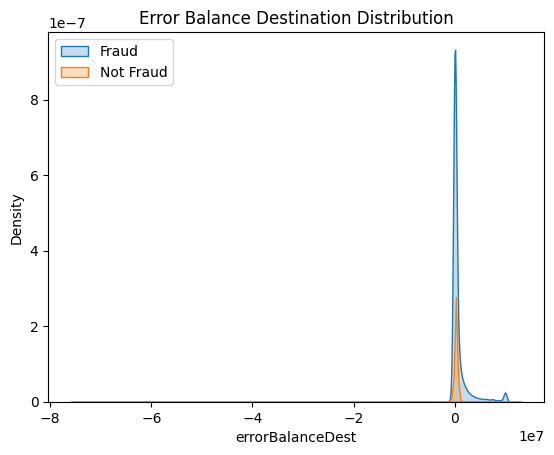

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(df[df['isFraud'] == 1]['errorBalanceDest'], label='Fraud', shade=True)
sns.kdeplot(df[df['isFraud'] == 0]['errorBalanceDest'], label='Not Fraud', shade=True)
plt.title("Error Balance Destination Distribution")
plt.legend()
plt.show()


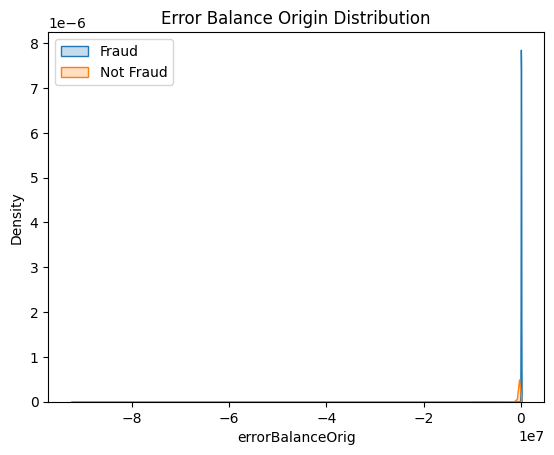

In [18]:
sns.kdeplot(df[df['isFraud'] == 1]['errorBalanceOrig'], label='Fraud', fill=True)
sns.kdeplot(df[df['isFraud'] == 0]['errorBalanceOrig'], label='Not Fraud', fill=True)
plt.title("Error Balance Origin Distribution")
plt.legend()
plt.show()


In [19]:
# Balance movements
df['balanceChangeOrig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balanceChangeDest'] = df['newbalanceDest'] - df['oldbalanceDest']

# Flag merchants
df['isMerchantDest'] = df['nameDest'].str.startswith('M').astype(int)

# Drop useless features
df = df.drop(['errorBalanceOrig', 'nameOrig', 'nameDest'], axis=1)


In [20]:
df = pd.get_dummies(df, columns=['type'], drop_first=True)


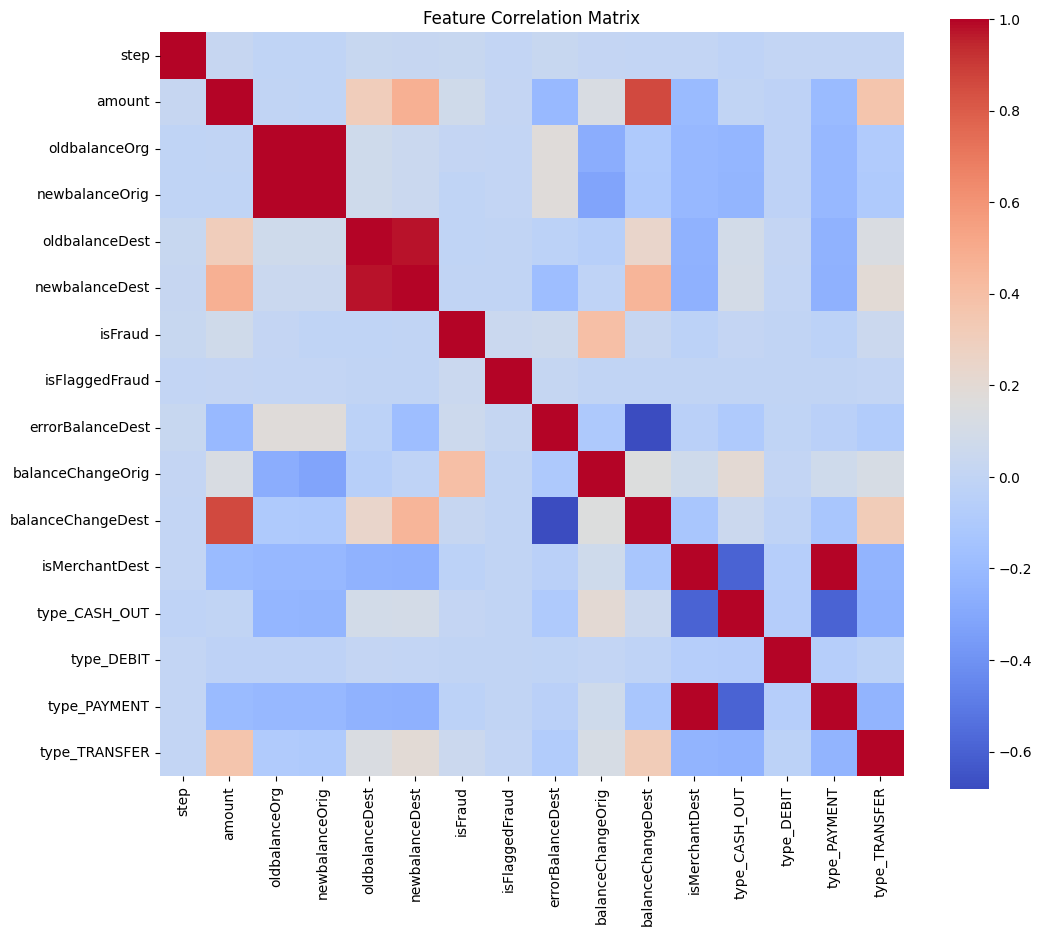

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', annot=False, square=True)
plt.title('Feature Correlation Matrix')
plt.show()


In [23]:
final_features = [
    'step',
    'amount',
    'oldbalanceOrg',
    'oldbalanceDest',
    'isFlaggedFraud',
    'errorBalanceDest',
    'balanceChangeOrig',
    'isMerchantDest',
    'type_CASH_OUT',
    'type_DEBIT',
    'type_TRANSFER'
]


In [24]:
from sklearn.model_selection import train_test_split

X = df[final_features]
y = df['isFraud']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',  
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_val)
y_proba = rf_model.predict_proba(X_val)[:, 1]  


              precision    recall  f1-score   support

           0     1.0000    0.9812    0.9905   1175374
           1     0.0680    0.9817    0.1271      1643

    accuracy                         0.9812   1177017
   macro avg     0.5340    0.9815    0.5588   1177017
weighted avg     0.9987    0.9812    0.9893   1177017

ROC AUC Score: 0.9980704125544879


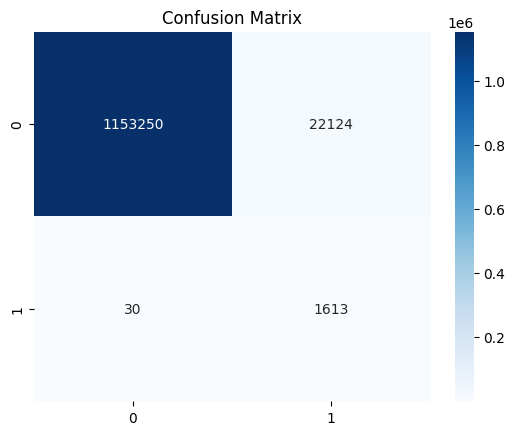

In [26]:
print(classification_report(y_val, y_pred, digits=4))
print("ROC AUC Score:", roc_auc_score(y_val, y_proba))

import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


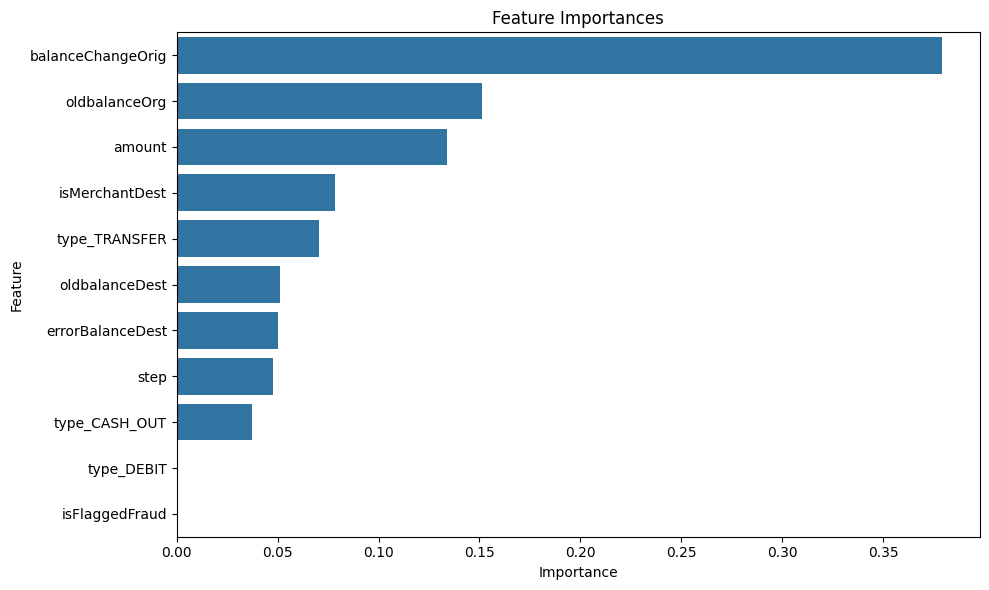

In [27]:
importances = rf_model.feature_importances_
features = X_train.columns

# Plot
import matplotlib.pyplot as plt
import seaborn as sns
feat_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_df)
plt.title("Feature Importances")
plt.tight_layout()
plt.show()
